# lxd-io

Create a `Dataset` object with to load a dataset. `lxd-io` automatically searches the relevant recordings and maps in the dataset folder.

In [27]:
from lxd_io import Dataset

# TODO: Replace by your path to dataset
dataset_path = "/home/hendrik/data/highD-dataset-v1.0"

dataset = Dataset(dataset_path)

2025-06-07 22:04:55.845 | DEBUG    | lxd_io.dataset:__init__:49 - Read dataset highd-1.0 from: /home/hendrik/data/highD-dataset-v1.0
2025-06-07 22:04:55.846 | DEBUG    | lxd_io.dataset:_explore_data_dir:175 - Search for recordings in: /home/hendrik/data/highD-dataset-v1.0/data
2025-06-07 22:04:55.874 | DEBUG    | lxd_io.dataset:_explore_data_dir:254 - Found complete data for 60 recordings:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
2025-06-07 22:04:55.875 | DEBUG    | lxd_io.dataset:_explore_maps_dir:261 - Search for maps in: /home/hendrik/data/highD-dataset-v1.0/maps
2025-06-07 22:04:55.876 | WARNING  | lxd_io.dataset:_explore_maps_dir:272 - No Lanelet2 map directories found.
2025-06-07 22:04:55.876 | WARNING  | lxd_io.dataset:_explore_maps_dir:289 - No OpenDrive map directories found.


The dataset object has some high-level properties like the dataset ID and version, a list of contained recordings, locations and a mapping between locations and recordings.

In [28]:
print(f"Dataset ID: {dataset.id}")
print(f"Dataset version: {dataset.version}")

print(f"Available recordings: {dataset.recording_ids}")
print(f"Available locations: {dataset.location_ids}")
print(f"Available recordings at locations: {dataset.recordings_at_location}")

Dataset ID: highd
Dataset version: 1.0
Available recordings: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
Available locations: [1, 2, 3, 4, 5, 6]
Available recordings at locations: {1: [11, 12, 13, 14, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57], 2: [1, 2, 3], 3: [4, 5, 6], 4: [7, 8, 9, 10], 5: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24], 6: [58, 59, 60]}


Get a specific recording as a `Recording` object to access. To get the recording with `recording_id` 1 from the dataset, use

In [29]:
print("Get a recording")
recording = dataset.get_recording(12)

2025-06-07 22:04:55.892 | DEBUG    | lxd_io.dataset:get_recording:371 - Get recording 12.
2025-06-07 22:04:55.894 | DEBUG    | lxd_io.recording:__init__:29 - Load csv files for recording 12.


Get a recording


A recording contains information about meta data, maps and tracks.

In [30]:
print("Recording meta data keys")
print(recording.meta_data_keys)

print("Recording location ID")
print(recording.location_id)

print("lanelet2 map file")
print(recording.lanelet2_map_file)

print("OpenDRIVE map file")
print(recording.opendrive_map_file)

# Get the list of track ids
print("Recording track ids")
print(f"First 20 track ids: {recording.track_ids[:20]}")
print(f"Total number of track ids: {len(recording.track_ids)}")

Recording meta data keys
['id', 'frameRate', 'locationId', 'speedLimit', 'month', 'weekDay', 'startTime', 'duration', 'totalDrivenDistance', 'totalDrivenTime', 'numVehicles', 'numCars', 'numTrucks', 'upperLaneMarkings', 'lowerLaneMarkings']
Recording location ID
1
lanelet2 map file
None
OpenDRIVE map file
None
Recording track ids
First 20 track ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Total number of track ids: 2728


It also has some convenience functions to filter tracks by frame.

In [31]:
# Get the list of frames
print("Recording frames")
print(f"First 20 recording frames: {recording.frames[:20]}")
print(f"Total number of recording frames: {len(recording.frames)}")

# Get track_ids at certain frame
track_ids_at_frame = recording.get_track_ids_at_frame(500)
print("Track ids at certain frame")
print(track_ids_at_frame)

2025-06-07 22:04:55.914 | DEBUG    | lxd_io.recording:_read_tracks_file:62 - Load tracks file for recording 12


Recording frames
First 20 recording frames: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Total number of recording frames: 22939
Track ids at certain frame
[44, 45, 56, 57, 58, 60, 62, 64, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]


To get a specific track (here: track with ID `25`), use

In [32]:
# Get a track
print("Get track 25")
track = recording.get_track(25)

Get track 25


A `Track` object contains meta data (`*_tracksMeta.csv`) as well as data (`*_tracks.csv`)

In [33]:
# Read meta data of track
print("Track meta data keys")
print(track.meta_data_keys)

initial_frame = track.get_meta_data("initialFrame")
print("Initial frame")
print(initial_frame)

# Read data of track
print("Track data keys")
print(track.data_keys)

lon_velocity = track.get_data("xVelocity")
print("Lon velocity")
print(lon_velocity[:20])

Track meta data keys
['id', 'width', 'height', 'initialFrame', 'finalFrame', 'numFrames', 'class', 'drivingDirection', 'traveledDistance', 'minXVelocity', 'maxXVelocity', 'meanXVelocity', 'minDHW', 'minTHW', 'minTTC', 'numLaneChanges']
Initial frame
1
Track data keys
['frame', 'id', 'x', 'y', 'width', 'height', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration', 'frontSightDistance', 'backSightDistance', 'dhw', 'thw', 'ttc', 'precedingXVelocity', 'precedingId', 'followingId', 'leftPrecedingId', 'leftAlongsideId', 'leftFollowingId', 'rightPrecedingId', 'rightAlongsideId', 'rightFollowingId', 'laneId']
Lon velocity
[26.36 26.37 26.37 26.38 26.39 26.4  26.41 26.42 26.43 26.44 26.45 26.46
 26.47 26.48 26.49 26.51 26.52 26.53 26.54 26.55]


Plot data

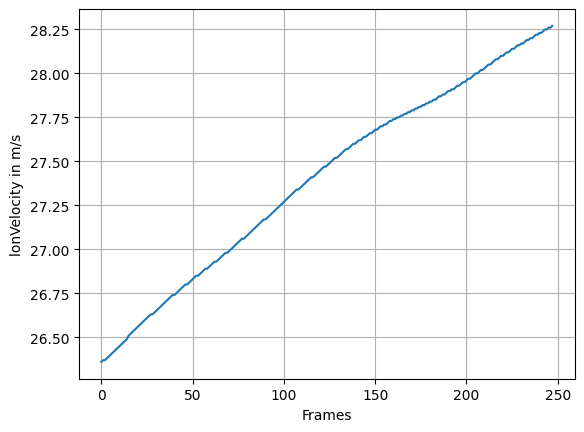

In [34]:
import matplotlib.pyplot as plt

plt.plot(lon_velocity)
plt.xlabel("Frames")
plt.ylabel("lonVelocity in m/s")
plt.grid()

Data can also be filtered by frame or frame ranges

In [35]:
# Read data at a certain frame
lon_velocity_at_frame = track.get_data_at_frame("xVelocity", initial_frame + 2)
print(f"lonVelocity at frame: {initial_frame + 2}")
print(lon_velocity_at_frame)

# Read data between frames
start_frame = initial_frame + 2
end_frame = initial_frame + 10
lon_velocity_between_frames = track.get_data_between_frames(
    "xVelocity", start_frame, end_frame
)
print(f"lonVelocity between frames: {start_frame}, {end_frame}")
print(lon_velocity_between_frames)

lonVelocity at frame: 3
26.37
lonVelocity between frames: 3, 11
[26.37 26.38 26.39 26.4  26.41 26.42 26.43 26.44 26.45]


A recording also contains convenvience methods to plot single or multiple tracks to the background image.

In [36]:
import matplotlib.pyplot as plt

Plot a single track

2025-06-07 22:04:56.218 | DEBUG    | lxd_io.recording:_plot_single_track:207 - Plot recording 12, track 25


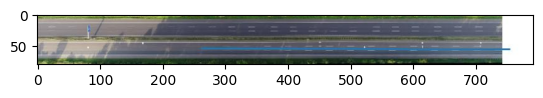

In [37]:
plot_file = recording.plot_track(25, ".")

im = plt.imread(plot_file)
plt.imshow(im)

Plot multiple tracks

2025-06-07 22:04:56.335 | DEBUG    | lxd_io.recording:_plot_multiple_tracks:244 - Plot recording 12, tracks [44, 45, 56, 57, 58, 60, 62, 64, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114]


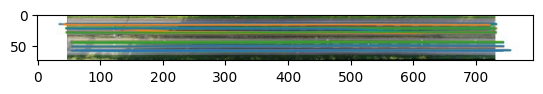

In [38]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#1f77b4', '#ff7f0e', '#2ca02c'])  # Custom color list
plot_file = recording.plot_track(track_ids_at_frame, ".")

im = plt.imread(plot_file)
plt.imshow(im)

2025-06-07 22:08:48.564 | DEBUG    | lxd_io.recording:_plot_multiple_tracks:244 - Plot recording 12, tracks [1115, 1110, 1009, 1016]


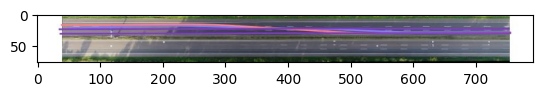

In [40]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#8080ff', '#ff8080', '#803dc0', '#803dc0'])  # Custom color list
plot_file = recording.plot_track([1115, 1110, 1009, 1016], ".")

im = plt.imread(plot_file)
plt.imshow(im)